# 04 — Sentiment Model Training

Fine-tunes `distilbert-base-uncased` (a **generic** pre-trained model, NOT pre-fine-tuned for sentiment)
on the **Financial PhraseBank** dataset (75% agreement split).

This satisfies the restriction:
> *'You may not use a model from Hugging Face that has already been fine-tuned for sentiment.'*

The base model is confirmed at:
https://huggingface.co/distilbert/distilbert-base-uncased
(no downstream fine-tuning — only masked language modelling pre-training)

In [1]:
!pip install -q datasets transformers evaluate accelerate scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
import evaluate
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for d in ["models", "outputs", "figures"]:
    Path(d).mkdir(exist_ok=True)

plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [3]:
# ── confirm base model is NOT pre-fine-tuned for sentiment ───────────────────
# distilbert-base-uncased is a general-purpose masked LM.
# Do NOT change this to distilbert-base-uncased-finetuned-sst-2-english
# or any other sentiment-specific model — that would violate the restriction.
BASE_MODEL = "distilbert-base-uncased"
print(f"Base model: {BASE_MODEL}")
print("Confirmed: generic pre-trained LM, no prior sentiment fine-tuning.")

Base model: distilbert-base-uncased
Confirmed: generic pre-trained LM, no prior sentiment fine-tuning.


In [4]:
# ── load Financial PhraseBank ─────────────────────────────────────────────────
# 75% agreement: sentences where >= 75% of annotators agreed on the label.
# Label map: 0 = negative, 1 = neutral, 2 = positive
raw = load_dataset("financial_phrasebank", "sentences_75agree")

# The dataset only has a 'train' split — we split it manually
split = raw["train"].train_test_split(test_size=0.2, seed=42)
print(split)

# Verify label distribution
label_counts = pd.Series(split["train"]["label"]).value_counts().sort_index()
label_counts.index = ["negative", "neutral", "positive"]
print("\nTrain label distribution:")
print(label_counts)

Using the latest cached version of the dataset since financial_phrasebank couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'sentences_75agree' at C:\Users\lola\.cache\huggingface\datasets\financial_phrasebank\sentences_75agree\1.0.0\550bde12e6c30e2674da973a55f57edde5181d53f5a5a34c1531c53f93b7e141 (last modified on Wed May 20 09:10:38 2026).


DatasetDict({
    train: Dataset({
        features: ['sentence', 'label'],
        num_rows: 2762
    })
    test: Dataset({
        features: ['sentence', 'label'],
        num_rows: 691
    })
})

Train label distribution:
negative     329
neutral     1708
positive     725
Name: count, dtype: int64


In [5]:
# ── tokenise ─────────────────────────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

def tokenize(batch):
    return tokenizer(
        batch["sentence"],
        padding="max_length",
        truncation=True,
        max_length=128,
    )

tokenized = split.map(tokenize, batched=True)
tokenized = tokenized.rename_column("label", "labels")
tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

print("Tokenisation complete.")

Map:   0%|          | 0/2762 [00:00<?, ? examples/s]

Map:   0%|          | 0/691 [00:00<?, ? examples/s]

Tokenisation complete.


In [6]:
# ── model ─────────────────────────────────────────────────────────────────────
model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL,
    num_labels=3,   # negative / neutral / positive
    id2label={0: "negative", 1: "neutral", 2: "positive"},
    label2id={"negative": 0, "neutral": 1, "positive": 2},
)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model parameters: 66,955,779


In [7]:
# ── metrics ───────────────────────────────────────────────────────────────────
accuracy_metric = evaluate.load("accuracy")
f1_metric       = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_metric.compute(
            predictions=preds, references=labels
        )["accuracy"],
        "macro_f1": f1_metric.compute(
            predictions=preds, references=labels, average="macro"
        )["f1"],
        "weighted_f1": f1_metric.compute(
            predictions=preds, references=labels, average="weighted"
        )["f1"],
    }

In [11]:
training_args = TrainingArguments(
    output_dir="models/sentiment_distilbert",
    eval_strategy="epoch", 
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="outputs/logs",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["test"],
    compute_metrics=compute_metrics,
)

trainer.train()

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
c:\Users\lola\anaconda3\envs\sentiment_hw\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,No log,0.254172,0.913169,0.891150,0.914815
2,No log,0.283117,0.908828,0.893697,0.911093
3,0.264129,0.243989,0.926194,0.905012,0.927154


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\lola\anaconda3\envs\sentiment_hw\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\lola\anaconda3\envs\sentiment_hw\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=519, training_loss=0.25873068072662647, metrics={'train_runtime': 3394.2458, 'train_samples_per_second': 2.441, 'train_steps_per_second': 0.153, 'total_flos': 274411109961216.0, 'train_loss': 0.25873068072662647, 'epoch': 3.0})

In [12]:
# ── evaluate ──────────────────────────────────────────────────────────────────
eval_results = trainer.evaluate()
print("\n=== Final Evaluation ===")
for k, v in eval_results.items():
    print(f"  {k}: {v:.4f}")

pd.DataFrame([eval_results]).to_csv("outputs/sentiment_eval_results.csv", index=False)

c:\Users\lola\anaconda3\envs\sentiment_hw\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,Weighted F1
0.264129,0.243989,3,0.926194,0.905012,0.927154



=== Final Evaluation ===
  eval_loss: 0.2440
  eval_accuracy: 0.9262
  eval_macro_f1: 0.9050
  eval_weighted_f1: 0.9272


c:\Users\lola\anaconda3\envs\sentiment_hw\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


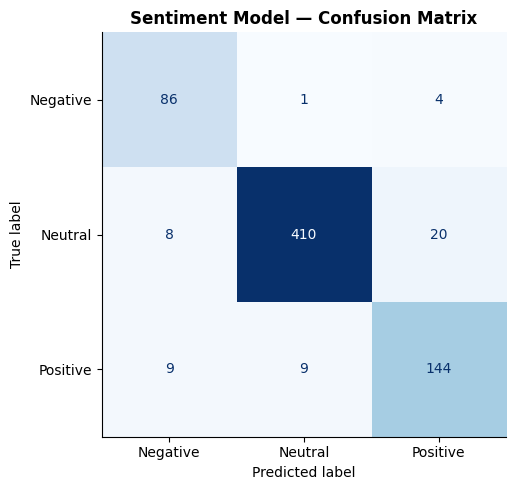

In [13]:
# ── confusion matrix ──────────────────────────────────────────────────────────
import torch

preds_output = trainer.predict(tokenized["test"])
y_pred = np.argmax(preds_output.predictions, axis=1)
y_true = preds_output.label_ids

cm = confusion_matrix(y_true, y_pred)
labels_str = ["Negative", "Neutral", "Positive"]

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_str)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Sentiment Model — Confusion Matrix", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/sentiment_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

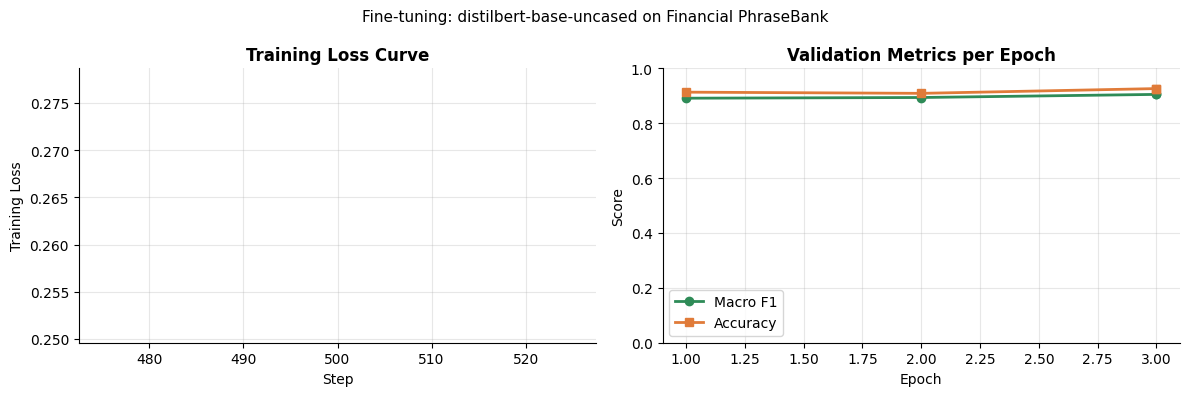

In [14]:
# ── training curve ────────────────────────────────────────────────────────────
log_history = pd.DataFrame(trainer.state.log_history)

# Separate train loss and eval metrics
train_log = log_history.dropna(subset=["loss"]).copy()
eval_log  = log_history.dropna(subset=["eval_macro_f1"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_log["step"], train_log["loss"], color="#4C72B0", linewidth=1.5)
axes[0].set_xlabel("Step"); axes[0].set_ylabel("Training Loss")
axes[0].set_title("Training Loss Curve", fontweight="bold")
axes[0].grid(alpha=0.3)

axes[1].plot(eval_log["epoch"], eval_log["eval_macro_f1"], marker="o", color="#2E8B57", linewidth=2)
axes[1].plot(eval_log["epoch"], eval_log["eval_accuracy"], marker="s", color="#E07B39", linewidth=2)
axes[1].legend(["Macro F1", "Accuracy"])
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Score")
axes[1].set_title("Validation Metrics per Epoch", fontweight="bold")
axes[1].set_ylim(0, 1); axes[1].grid(alpha=0.3)

plt.suptitle("Fine-tuning: distilbert-base-uncased on Financial PhraseBank", fontsize=11)
plt.tight_layout()
plt.savefig("figures/sentiment_training_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# ── save final model ──────────────────────────────────────────────────────────
FINAL_MODEL_PATH = "models/sentiment_distilbert_final"
trainer.save_model(FINAL_MODEL_PATH)
tokenizer.save_pretrained(FINAL_MODEL_PATH)
print(f"Model saved to {FINAL_MODEL_PATH}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to models/sentiment_distilbert_final


: 